# CLIP CUB-200: Semantic, Language Prior, Prompt Sensitivity Probe

CUB-200에서 corruption 전후 CLIP 예측을 정량적으로 분해합니다.

- **Semantic drift**: true class와 predicted class의 CLIP text embedding 유사도
- **Language prior / hubness**: class 이름 text embedding 자체가 중심적이거나 nearest-neighbor hub인지, 그리고 오분류가 그쪽으로 몰리는지
- **Prompt sensitivity**: prompt template 변화에 따른 top-1 flip, confidence range/std, probability distribution JSD

샘플 수와 corruption 설정만 바꿔가며 반복 실험할 수 있게 구성했습니다.

In [1]:
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image

try:
    import open_clip
except ImportError as exc:
    raise ImportError("open_clip_torch가 필요합니다. repo root에서 `pip install -r requirements.txt` 실행 후 다시 시도하세요.") from exc

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "utils" / "corruptions.py").exists():
    REPO_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(REPO_ROOT))

from utils.corruptions import apply_corruption

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Metric definitions

`semantic_similarity_true_pred`: CLIP text embedding에서 true label prompt와 predicted label prompt의 cosine similarity입니다. 오분류가 의미적으로 가까운 새 이름으로 가는지 봅니다.

`text_centrality`: 어떤 class text embedding이 다른 모든 class text embedding과 평균적으로 얼마나 가까운지입니다. 높으면 class name/prompt 자체가 language space의 중심에 있습니다.

`text_knn_hub_count`: 다른 class들의 text nearest-neighbor top-k에 해당 class가 몇 번 등장하는지입니다. 높으면 language-space hub 후보입니다.

`prompt_top1_flip_rate`: 같은 이미지/condition에서 prompt template를 바꿨을 때 top-1 prediction이 얼마나 자주 dominant prediction에서 벗어나는지입니다.

`prompt_jsd_mean`: prompt별 전체 200-class probability distribution 사이의 평균 Jensen-Shannon divergence입니다.

In [2]:
DATA_ROOT = REPO_ROOT / "data" / "cub200_prepared"
SPLIT = "test"

N_SAMPLES = 64
SEED = 7

# utils/corruptions.py: gaussian_noise, motion_blur, brightness, contrast, jpeg_compression, downsample_upsample
CORRUPTION = "gaussian_noise"
SEVERITY = 3

MODEL_NAME = "ViT-B-32"
PRETRAINED = "openai"
TEXT_KNN_K = 10

PROMPT_TEMPLATES = {
    "bare": "{}",
    "photo": "a photo of a {}",
    "bird_photo": "a photo of a {}, a type of bird",
    "wild_bird": "a wildlife photo of a {} bird",
    "cropped": "a cropped photo of the {} bird",
    "low_quality": "a low quality photo of a {} bird",
    "noisy": "a noisy corrupted photo of a {} bird",
}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

DEVICE

device(type='mps')

In [3]:
def cub_folder_to_label(folder_name: str) -> str:
    name = folder_name.split(".", 1)[1] if "." in folder_name else folder_name
    return name.replace("_", " ").lower()


def collect_cub_images(root: Path, split: str):
    split_dir = root / split
    if not split_dir.exists():
        raise FileNotFoundError(f"CUB split 경로가 없습니다: {split_dir}")

    class_dirs = sorted([p for p in split_dir.iterdir() if p.is_dir()])
    classes = [cub_folder_to_label(p.name) for p in class_dirs]
    records = []
    for class_dir, label in zip(class_dirs, classes):
        for path in sorted(class_dir.iterdir()):
            if path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}:
                records.append({"path": path, "true_label": label, "class_dir": class_dir.name})
    return classes, records


classes, image_records = collect_cub_images(DATA_ROOT, SPLIT)
class_to_idx = {label: idx for idx, label in enumerate(classes)}

print(f"classes: {len(classes)}")
print(f"images found: {len(image_records)}")
print(f"data split: {DATA_ROOT / SPLIT}")

if len(image_records) == 0:
    raise RuntimeError("이미지 파일을 찾지 못했습니다. symlink target, DATA_ROOT, SPLIT 설정을 확인하세요.")

sample_records = random.sample(image_records, k=min(N_SAMPLES, len(image_records)))
pd.DataFrame(sample_records).head()

classes: 200
images found: 5794
data split: /Users/taehayeong/Desktop/Git_workspace/lab/data/cub200_prepared/test


,path,true_label,class_dir
0,/Users/taehayeong/Desktop/Git_workspace/lab/da...,clark nutcracker,093.Clark_Nutcracker
1,/Users/taehayeong/Desktop/Git_workspace/lab/da...,northern fulmar,045.Northern_Fulmar
2,/Users/taehayeong/Desktop/Git_workspace/lab/da...,black throated sparrow,114.Black_throated_Sparrow
3,/Users/taehayeong/Desktop/Git_workspace/lab/da...,bohemian waxwing,185.Bohemian_Waxwing
4,/Users/taehayeong/Desktop/Git_workspace/lab/da...,painted bunting,016.Painted_Bunting


In [4]:
model, _, preprocess = open_clip.create_model_and_transforms(
    MODEL_NAME,
    pretrained=PRETRAINED,
    device=DEVICE,
)
tokenizer = open_clip.get_tokenizer(MODEL_NAME)
model.eval()

print(f"Loaded {MODEL_NAME}/{PRETRAINED} on {DEVICE}")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Loaded ViT-B-32/openai on mps


In [5]:
def encode_texts(texts, batch_size=256):
    features = []
    with torch.no_grad():
        for start in range(0, len(texts), batch_size):
            tokens = tokenizer(texts[start:start + batch_size]).to(DEVICE)
            feat = model.encode_text(tokens)
            feat = feat / feat.norm(dim=-1, keepdim=True)
            features.append(feat.detach().cpu())
    return torch.cat(features, dim=0)


text_features_by_prompt = {}
text_prior_rows = []

for prompt_name, template in PROMPT_TEMPLATES.items():
    prompts = [template.format(label) for label in classes]
    text_features = encode_texts(prompts)
    text_features_by_prompt[prompt_name] = text_features

    sim = text_features @ text_features.T
    sim_no_self = sim.clone()
    sim_no_self.fill_diagonal_(float("nan"))
    centrality = torch.nanmean(sim_no_self, dim=1).numpy()

    sim_for_knn = sim.clone()
    sim_for_knn.fill_diagonal_(-float("inf"))
    knn = torch.topk(sim_for_knn, k=TEXT_KNN_K, dim=1).indices.numpy().reshape(-1)
    hub_count = np.bincount(knn, minlength=len(classes))

    for idx, label in enumerate(classes):
        text_prior_rows.append({
            "prompt_name": prompt_name,
            "class_idx": idx,
            "class_label": label,
            "text_centrality": float(centrality[idx]),
            "text_knn_hub_count": int(hub_count[idx]),
        })

text_prior_df = pd.DataFrame(text_prior_rows)
text_prior_df.sort_values(["prompt_name", "text_knn_hub_count", "text_centrality"], ascending=[True, False, False]).head(12)

,prompt_name,class_idx,class_label,text_centrality,text_knn_hub_count
38,bare,38,least flycatcher,0.728566,48
28,bare,28,american crow,0.713066,43
29,bare,29,fish crow,0.714275,41
117,bare,117,house sparrow,0.716929,39
169,bare,169,mourning warbler,0.720956,35
178,bare,178,tennessee warbler,0.718857,35
160,bare,160,blue winged warbler,0.716101,35
42,bare,42,yellow bellied flycatcher,0.709218,34
156,bare,156,yellow throated vireo,0.709396,32
65,bare,65,western gull,0.702942,32


## Language-space hub 후보

이미지를 보지 않고 class prompt text embedding만으로 계산한 hub입니다. 이후 corrupted 오분류가 이 class들로 몰리는지 비교합니다.

In [6]:
base_prompt = "bird_photo"
display(
    text_prior_df[text_prior_df.prompt_name == base_prompt]
    .sort_values(["text_knn_hub_count", "text_centrality"], ascending=False)
    .head(20)
    .style.format({"text_centrality": "{:.3f}"})
)

,prompt_name,class_idx,class_label,text_centrality,text_knn_hub_count
438,bird_photo,38,least flycatcher,0.782,57
428,bird_photo,28,american crow,0.758,46
578,bird_photo,178,tennessee warbler,0.770,41
512,bird_photo,112,baird sparrow,0.760,41
569,bird_photo,169,mourning warbler,0.770,40
429,bird_photo,29,fish crow,0.756,39
517,bird_photo,117,house sparrow,0.764,37
442,bird_photo,42,yellow bellied flycatcher,0.760,36
465,bird_photo,65,western gull,0.749,35
528,bird_photo,128,song sparrow,0.745,31


In [7]:
def encode_pil_images(images, batch_size=32):
    feats = []
    with torch.no_grad():
        for start in range(0, len(images), batch_size):
            batch = torch.stack([preprocess(img) for img in images[start:start + batch_size]]).to(DEVICE)
            feat = model.encode_image(batch)
            feat = feat / feat.norm(dim=-1, keepdim=True)
            feats.append(feat.detach().cpu())
    return torch.cat(feats, dim=0)


clean_images = []
corrupted_images = []
for record in sample_records:
    image = Image.open(record["path"]).convert("RGB")
    clean_images.append(image)
    corrupted_images.append(apply_corruption(image, CORRUPTION, SEVERITY))

clean_image_features = encode_pil_images(clean_images)
corrupted_image_features = encode_pil_images(corrupted_images)
image_feature_cosine = F.cosine_similarity(clean_image_features, corrupted_image_features).numpy()

print(f"encoded images: {len(sample_records)} clean + corrupted")
print(f"mean clean/corrupted image feature cosine: {image_feature_cosine.mean():.3f}")

encoded images: 64 clean + corrupted
mean clean/corrupted image feature cosine: 0.902


In [8]:
def probs_from_features(image_features, text_features):
    logits = 100.0 * image_features @ text_features.T
    return logits.softmax(dim=-1)


pred_rows = []
prob_bank = {}

for prompt_name, text_features in text_features_by_prompt.items():
    for condition, image_features in [
        ("clean", clean_image_features),
        (f"{CORRUPTION}_s{SEVERITY}", corrupted_image_features),
    ]:
        probs = probs_from_features(image_features, text_features)
        prob_bank[(prompt_name, condition)] = probs.numpy()
        top_probs, top_indices = probs.max(dim=1)

        sim = text_features @ text_features.T
        prior = text_prior_df[text_prior_df.prompt_name == prompt_name].set_index("class_label")

        for sample_id, record in enumerate(sample_records):
            true_label = record["true_label"]
            true_idx = class_to_idx[true_label]
            pred_idx = int(top_indices[sample_id])
            pred_label = classes[pred_idx]

            sample_probs = probs[sample_id]
            false_probs = sample_probs.clone()
            false_probs[true_idx] = -float("inf")
            margin = float(sample_probs[true_idx] - false_probs.max())

            pred_rows.append({
                "sample_id": sample_id,
                "condition": condition,
                "prompt_name": prompt_name,
                "path": str(record["path"]),
                "true_label": true_label,
                "pred_label": pred_label,
                "confidence": float(top_probs[sample_id]),
                "true_prob": float(sample_probs[true_idx]),
                "margin_true_vs_best_false": margin,
                "correct": pred_label == true_label,
                "semantic_similarity_true_pred": float(sim[true_idx, pred_idx]),
                "text_centrality_pred": float(prior.loc[pred_label, "text_centrality"]),
                "text_knn_hub_count_pred": int(prior.loc[pred_label, "text_knn_hub_count"]),
                "image_feature_cosine_clean_corrupted": float(image_feature_cosine[sample_id]),
            })

pred_df = pd.DataFrame(pred_rows)
pred_df.head()

,sample_id,condition,prompt_name,path,true_label,pred_label,confidence,true_prob,margin_true_vs_best_false,correct,semantic_similarity_true_pred,text_centrality_pred,text_knn_hub_count_pred,image_feature_cosine_clean_corrupted
0,0,clean,bare,/Users/taehayeong/Desktop/Git_workspace/lab/da...,clark nutcracker,rock wren,0.151877,0.059005,-0.092872,False,0.698119,0.706902,8,0.822999
1,1,clean,bare,/Users/taehayeong/Desktop/Git_workspace/lab/da...,northern fulmar,northern fulmar,0.708559,0.708559,0.658632,True,1.000000,0.644491,11,0.862229
2,2,clean,bare,/Users/taehayeong/Desktop/Git_workspace/lab/da...,black throated sparrow,great grey shrike,0.207386,0.033633,-0.173754,False,0.713905,0.671370,3,0.940026
3,3,clean,bare,/Users/taehayeong/Desktop/Git_workspace/lab/da...,bohemian waxwing,bohemian waxwing,0.946494,0.946494,0.936656,True,1.000000,0.654337,1,0.878228
4,4,clean,bare,/Users/taehayeong/Desktop/Git_workspace/lab/da...,painted bunting,painted bunting,0.808492,0.808492,0.697563,True,1.000000,0.659359,3,0.958576


## Prompt별 clean/corrupted 성능과 semantic drift

In [9]:
summary = (
    pred_df.groupby(["prompt_name", "condition"])
    .agg(
        accuracy=("correct", "mean"),
        mean_confidence=("confidence", "mean"),
        median_confidence=("confidence", "median"),
        mean_true_prob=("true_prob", "mean"),
        mean_margin=("margin_true_vs_best_false", "mean"),
        mean_semantic_similarity=("semantic_similarity_true_pred", "mean"),
    )
    .reset_index()
)

display(summary.style.format({
    "accuracy": "{:.3f}",
    "mean_confidence": "{:.3f}",
    "median_confidence": "{:.3f}",
    "mean_true_prob": "{:.3f}",
    "mean_margin": "{:+.3f}",
    "mean_semantic_similarity": "{:.3f}",
}))

,prompt_name,condition,accuracy,mean_confidence,median_confidence,mean_true_prob,mean_margin,mean_semantic_similarity
0,bare,clean,0.344,0.393,0.302,0.272,+0.073,0.865
1,bare,gaussian_noise_s3,0.281,0.370,0.288,0.216,+0.000,0.834
2,bird_photo,clean,0.328,0.380,0.282,0.268,+0.074,0.897
3,bird_photo,gaussian_noise_s3,0.266,0.358,0.276,0.222,+0.024,0.873
4,cropped,clean,0.328,0.365,0.255,0.265,+0.086,0.901
5,cropped,gaussian_noise_s3,0.281,0.340,0.236,0.215,+0.026,0.887
6,low_quality,clean,0.375,0.325,0.222,0.230,+0.066,0.924
7,low_quality,gaussian_noise_s3,0.281,0.291,0.207,0.191,+0.034,0.908
8,noisy,clean,0.312,0.354,0.234,0.253,+0.078,0.912
9,noisy,gaussian_noise_s3,0.250,0.322,0.220,0.206,+0.031,0.896


In [10]:
corr_condition = f"{CORRUPTION}_s{SEVERITY}"
clean_summary = summary[summary.condition == "clean"].set_index("prompt_name")
corr_summary = summary[summary.condition == corr_condition].set_index("prompt_name")

delta = corr_summary[["accuracy", "mean_confidence", "mean_true_prob", "mean_margin", "mean_semantic_similarity"]] - clean_summary[["accuracy", "mean_confidence", "mean_true_prob", "mean_margin", "mean_semantic_similarity"]]
delta = delta.reset_index().rename(columns={
    "accuracy": "delta_accuracy",
    "mean_confidence": "delta_mean_confidence",
    "mean_true_prob": "delta_mean_true_prob",
    "mean_margin": "delta_mean_margin",
    "mean_semantic_similarity": "delta_mean_semantic_similarity",
})

display(delta.sort_values("delta_accuracy").style.format({
    "delta_accuracy": "{:+.3f}",
    "delta_mean_confidence": "{:+.3f}",
    "delta_mean_true_prob": "{:+.3f}",
    "delta_mean_margin": "{:+.3f}",
    "delta_mean_semantic_similarity": "{:+.3f}",
}))

,prompt_name,delta_accuracy,delta_mean_confidence,delta_mean_true_prob,delta_mean_margin,delta_mean_semantic_similarity
6,wild_bird,-0.109,-0.035,-0.049,-0.049,-0.027
3,low_quality,-0.094,-0.035,-0.039,-0.032,-0.016
0,bare,-0.062,-0.023,-0.055,-0.073,-0.032
1,bird_photo,-0.062,-0.022,-0.046,-0.050,-0.024
4,noisy,-0.062,-0.033,-0.047,-0.047,-0.017
5,photo,-0.062,-0.013,-0.047,-0.059,-0.027
2,cropped,-0.047,-0.025,-0.051,-0.059,-0.014


## Prompt sensitivity

같은 이미지에서 prompt만 바꿨을 때 prediction과 probability distribution이 얼마나 흔들리는지 봅니다.

In [11]:
def js_divergence(p, q, eps=1e-12):
    p = np.asarray(p, dtype=np.float64) + eps
    q = np.asarray(q, dtype=np.float64) + eps
    p = p / p.sum()
    q = q / q.sum()
    m = 0.5 * (p + q)
    return 0.5 * np.sum(p * np.log(p / m)) + 0.5 * np.sum(q * np.log(q / m))


sensitivity_rows = []
prompt_names = list(PROMPT_TEMPLATES.keys())

for condition in ["clean", corr_condition]:
    for sample_id, record in enumerate(sample_records):
        rows = pred_df[(pred_df.condition == condition) & (pred_df.sample_id == sample_id)]
        pred_counts = rows.pred_label.value_counts()
        dominant_count = int(pred_counts.iloc[0])

        distributions = [prob_bank[(prompt_name, condition)][sample_id] for prompt_name in prompt_names]
        jsds = []
        for i in range(len(distributions)):
            for j in range(i + 1, len(distributions)):
                jsds.append(js_divergence(distributions[i], distributions[j]))

        sensitivity_rows.append({
            "sample_id": sample_id,
            "condition": condition,
            "true_label": record["true_label"],
            "prompt_unique_top1": int(pred_counts.shape[0]),
            "prompt_top1_flip_rate": 1.0 - dominant_count / len(prompt_names),
            "prompt_confidence_std": float(rows.confidence.std(ddof=0)),
            "prompt_confidence_range": float(rows.confidence.max() - rows.confidence.min()),
            "prompt_jsd_mean": float(np.mean(jsds)),
            "dominant_prediction": pred_counts.index[0],
            "dominant_prediction_count": dominant_count,
            "image_feature_cosine_clean_corrupted": float(image_feature_cosine[sample_id]),
        })

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_summary = sensitivity_df.groupby("condition").agg(
    mean_unique_top1=("prompt_unique_top1", "mean"),
    mean_top1_flip_rate=("prompt_top1_flip_rate", "mean"),
    mean_confidence_std=("prompt_confidence_std", "mean"),
    mean_confidence_range=("prompt_confidence_range", "mean"),
    mean_jsd=("prompt_jsd_mean", "mean"),
).reset_index()

display(sensitivity_summary.style.format({
    "mean_unique_top1": "{:.2f}",
    "mean_top1_flip_rate": "{:.3f}",
    "mean_confidence_std": "{:.3f}",
    "mean_confidence_range": "{:.3f}",
    "mean_jsd": "{:.4f}",
}))

,condition,mean_unique_top1,mean_top1_flip_rate,mean_confidence_std,mean_confidence_range,mean_jsd
0,clean,1.77,0.156,0.044,0.132,0.0241
1,gaussian_noise_s3,1.83,0.179,0.053,0.158,0.0310


In [12]:
display(
    sensitivity_df.sort_values(["condition", "prompt_top1_flip_rate", "prompt_jsd_mean"], ascending=[True, False, False])
    .head(20)
    .style.format({
        "prompt_top1_flip_rate": "{:.3f}",
        "prompt_confidence_std": "{:.3f}",
        "prompt_confidence_range": "{:.3f}",
        "prompt_jsd_mean": "{:.4f}",
        "image_feature_cosine_clean_corrupted": "{:.3f}",
    })
)

,sample_id,condition,true_label,prompt_unique_top1,prompt_top1_flip_rate,prompt_confidence_std,prompt_confidence_range,prompt_jsd_mean,dominant_prediction,dominant_prediction_count,image_feature_cosine_clean_corrupted
2,2,clean,black throated sparrow,3,0.571,0.058,0.163,0.0560,mockingbird,3,0.940
16,16,clean,fox sparrow,4,0.571,0.035,0.111,0.0396,sage thrasher,3,0.848
51,51,clean,worm eating warbler,3,0.571,0.029,0.084,0.0326,ovenbird,3,0.879
29,29,clean,yellow breasted chat,3,0.571,0.049,0.162,0.0312,common yellowthroat,3,0.925
31,31,clean,hooded warbler,3,0.571,0.034,0.109,0.0214,hooded warbler,3,0.922
5,5,clean,brandt cormorant,2,0.429,0.121,0.323,0.0641,pelagic cormorant,4,0.883
49,49,clean,golden winged warbler,3,0.429,0.056,0.159,0.0308,kentucky warbler,4,0.941
15,15,clean,lincoln sparrow,2,0.429,0.038,0.112,0.0218,henslow sparrow,4,0.886
59,59,clean,prairie warbler,2,0.429,0.043,0.125,0.0187,cape may warbler,4,0.919
21,21,clean,harris sparrow,4,0.429,0.009,0.028,0.0169,field sparrow,4,0.862


## Language prior와 corrupted hubness 연결

Corrupted 오분류가 많이 몰린 predicted class가 text-only centrality/hubness도 높은지 봅니다. 상관이 양수면 language prior/hub 설명이 강해집니다.

In [13]:
wrong_corr = pred_df[(pred_df.condition == corr_condition) & (~pred_df.correct)].copy()
wrong_hub = (
    wrong_corr.groupby(["prompt_name", "pred_label"])
    .agg(
        corrupted_wrong_count=("pred_label", "size"),
        mean_wrong_confidence=("confidence", "mean"),
        mean_semantic_similarity=("semantic_similarity_true_pred", "mean"),
        text_centrality_pred=("text_centrality_pred", "mean"),
        text_knn_hub_count_pred=("text_knn_hub_count_pred", "mean"),
    )
    .reset_index()
)

correlations = []
for prompt_name, group in wrong_hub.groupby("prompt_name"):
    if len(group) < 3:
        continue
    correlations.append({
        "prompt_name": prompt_name,
        "corr_wrong_count_vs_text_centrality": group["corrupted_wrong_count"].corr(group["text_centrality_pred"], method="spearman"),
        "corr_wrong_count_vs_text_knn_hub_count": group["corrupted_wrong_count"].corr(group["text_knn_hub_count_pred"], method="spearman"),
        "n_wrong_pred_classes": len(group),
    })

corr_df = pd.DataFrame(correlations)
display(corr_df.style.format({
    "corr_wrong_count_vs_text_centrality": "{:+.3f}",
    "corr_wrong_count_vs_text_knn_hub_count": "{:+.3f}",
}))

display(
    wrong_hub[wrong_hub.prompt_name == base_prompt]
    .sort_values(["corrupted_wrong_count", "mean_wrong_confidence"], ascending=False)
    .head(25)
    .style.format({
        "mean_wrong_confidence": "{:.3f}",
        "mean_semantic_similarity": "{:.3f}",
        "text_centrality_pred": "{:.3f}",
        "text_knn_hub_count_pred": "{:.1f}",
    })
)

,prompt_name,corr_wrong_count_vs_text_centrality,corr_wrong_count_vs_text_knn_hub_count,n_wrong_pred_classes
0,bare,-0.017,-0.029,34
1,bird_photo,+0.043,+0.288,34
2,cropped,-0.056,+0.046,33
3,low_quality,-0.101,+0.047,36
4,noisy,+0.054,+0.201,37
5,photo,+0.127,+0.107,32
6,wild_bird,+0.190,+0.259,34


,prompt_name,pred_label,corrupted_wrong_count,mean_wrong_confidence,mean_semantic_similarity,text_centrality_pred,text_knn_hub_count_pred
52,bird_photo,kentucky warbler,7,0.300,0.833,0.738,17.0
49,bird_photo,glaucous winged gull,3,0.252,0.838,0.716,20.0
41,bird_photo,california gull,2,0.343,0.903,0.730,23.0
40,bird_photo,boat tailed grackle,2,0.256,0.849,0.706,10.0
46,bird_photo,common yellowthroat,2,0.218,0.752,0.665,2.0
62,bird_photo,song sparrow,2,0.179,0.863,0.745,31.0
63,bird_photo,tennessee warbler,2,0.092,0.825,0.770,41.0
42,bird_photo,cape may warbler,1,0.542,0.824,0.708,9.0
37,bird_photo,black tern,1,0.456,0.749,0.724,10.0
36,bird_photo,black billed cuckoo,1,0.418,0.867,0.722,2.0


## Semantic error 분석

오분류가 의미적으로 가까운 class로 가는지, 아니면 language/image corruption 때문에 먼 class로 튀는지 봅니다.

In [14]:
semantic_error_summary = (
    pred_df.groupby(["prompt_name", "condition", "correct"])
    .agg(
        n=("sample_id", "size"),
        mean_semantic_similarity=("semantic_similarity_true_pred", "mean"),
        median_semantic_similarity=("semantic_similarity_true_pred", "median"),
        mean_confidence=("confidence", "mean"),
    )
    .reset_index()
)

display(semantic_error_summary.style.format({
    "mean_semantic_similarity": "{:.3f}",
    "median_semantic_similarity": "{:.3f}",
    "mean_confidence": "{:.3f}",
}))

display(
    pred_df[(pred_df.condition == corr_condition) & (~pred_df.correct)]
    .sort_values(["semantic_similarity_true_pred", "confidence"], ascending=[True, False])
    [["sample_id", "prompt_name", "true_label", "pred_label", "confidence", "semantic_similarity_true_pred", "text_centrality_pred", "text_knn_hub_count_pred"]]
    .head(25)
    .style.format({
        "confidence": "{:.3f}",
        "semantic_similarity_true_pred": "{:.3f}",
        "text_centrality_pred": "{:.3f}",
    })
)

,prompt_name,condition,correct,n,mean_semantic_similarity,median_semantic_similarity,mean_confidence
0,bare,clean,False,42,0.795,0.798,0.257
1,bare,clean,True,22,1.000,1.000,0.653
2,bare,gaussian_noise_s3,False,46,0.769,0.773,0.269
3,bare,gaussian_noise_s3,True,18,1.000,1.000,0.631
4,bird_photo,clean,False,43,0.847,0.848,0.243
5,bird_photo,clean,True,21,1.000,1.000,0.659
6,bird_photo,gaussian_noise_s3,False,47,0.827,0.829,0.244
7,bird_photo,gaussian_noise_s3,True,17,1.000,1.000,0.673
8,cropped,clean,False,43,0.852,0.849,0.227
9,cropped,clean,True,21,1.000,1.000,0.648


,sample_id,prompt_name,true_label,pred_label,confidence,semantic_similarity_true_pred,text_centrality_pred,text_knn_hub_count_pred
102,38,bare,red legged kittiwake,clark nutcracker,0.509,0.612,0.659,2
71,7,bare,fish crow,parakeet auklet,0.132,0.633,0.619,3
205,13,photo,bobolink,groove billed ani,0.154,0.649,0.659,2
96,32,bare,black throated sparrow,hooded merganser,0.130,0.652,0.648,6
77,13,bare,bobolink,clark nutcracker,0.193,0.652,0.659,2
91,27,bare,swainson warbler,carolina wren,0.284,0.660,0.625,5
94,30,bare,cerulean warbler,tree swallow,0.113,0.667,0.628,4
222,30,photo,cerulean warbler,tree swallow,0.149,0.676,0.638,3
219,27,photo,swainson warbler,carolina wren,0.256,0.678,0.637,5
230,38,photo,red legged kittiwake,clark nutcracker,0.375,0.684,0.693,3


## Plots

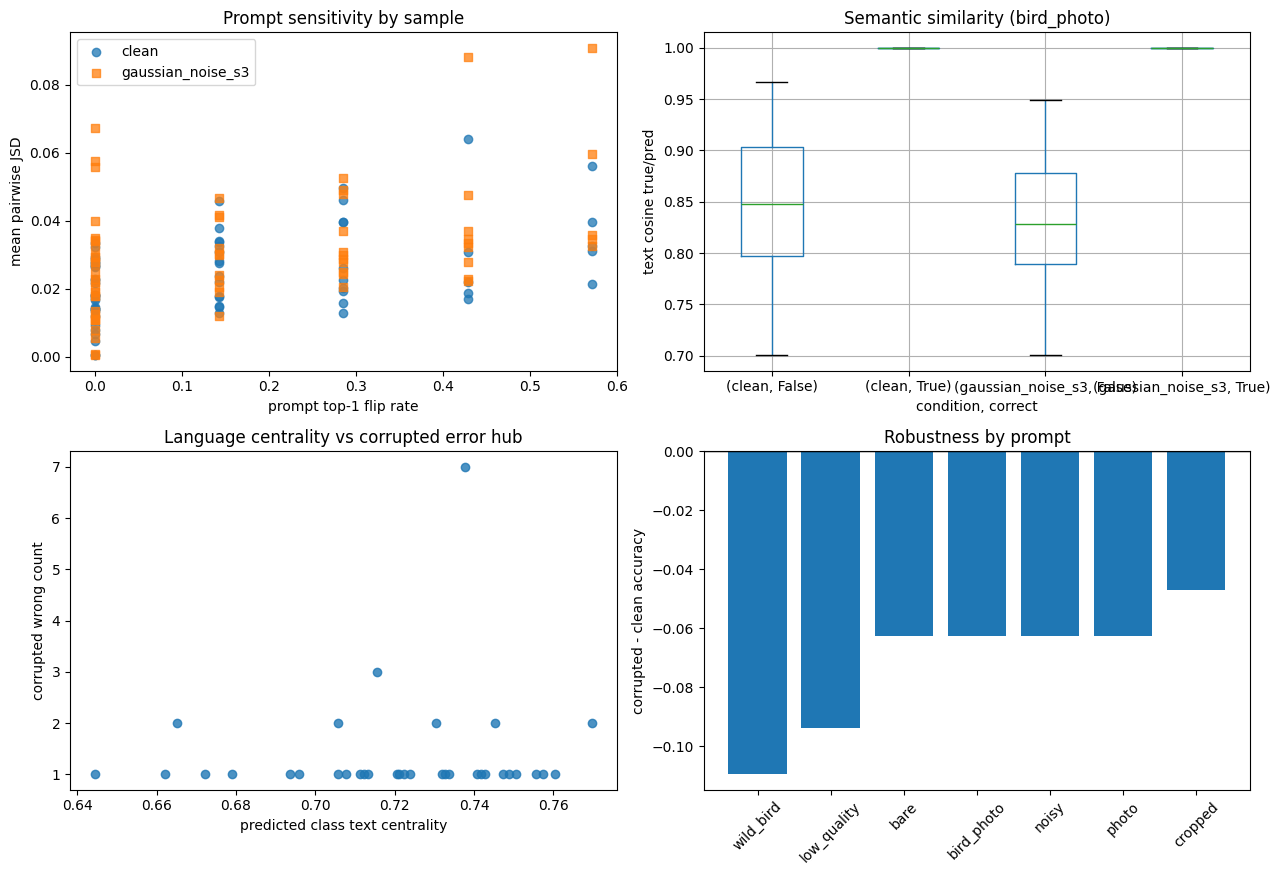

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for condition, marker in [("clean", "o"), (corr_condition, "s")]:
    subset = sensitivity_df[sensitivity_df.condition == condition]
    axes[0, 0].scatter(subset.prompt_top1_flip_rate, subset.prompt_jsd_mean, alpha=0.75, label=condition, marker=marker)
axes[0, 0].set_xlabel("prompt top-1 flip rate")
axes[0, 0].set_ylabel("mean pairwise JSD")
axes[0, 0].set_title("Prompt sensitivity by sample")
axes[0, 0].legend()

base = pred_df[pred_df.prompt_name == base_prompt]
base.boxplot(column="semantic_similarity_true_pred", by=["condition", "correct"], ax=axes[0, 1])
axes[0, 1].set_title(f"Semantic similarity ({base_prompt})")
axes[0, 1].set_xlabel("condition, correct")
axes[0, 1].set_ylabel("text cosine true/pred")

hub_base = wrong_hub[wrong_hub.prompt_name == base_prompt]
axes[1, 0].scatter(hub_base.text_centrality_pred, hub_base.corrupted_wrong_count, alpha=0.8)
axes[1, 0].set_xlabel("predicted class text centrality")
axes[1, 0].set_ylabel("corrupted wrong count")
axes[1, 0].set_title("Language centrality vs corrupted error hub")

delta_plot = delta.set_index("prompt_name").sort_values("delta_accuracy")
axes[1, 1].bar(delta_plot.index, delta_plot.delta_accuracy)
axes[1, 1].axhline(0, color="black", linewidth=1)
axes[1, 1].set_ylabel("corrupted - clean accuracy")
axes[1, 1].set_title("Robustness by prompt")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.suptitle("")
plt.tight_layout()
plt.show()

## Diagnostic scorecard

아래 표는 실험을 여러 번 반복할 때 비교하기 위한 요약 지표입니다. 값 자체보다 corruption/prompt/sample size를 바꿨을 때 방향성이 반복되는지가 중요합니다.

In [16]:
base_clean = pred_df[(pred_df.prompt_name == base_prompt) & (pred_df.condition == "clean")].set_index("sample_id")
base_corr = pred_df[(pred_df.prompt_name == base_prompt) & (pred_df.condition == corr_condition)].set_index("sample_id")

overconf_mask = (~base_corr.correct) & (base_corr.confidence > base_clean.confidence)
correct_to_wrong_mask = base_clean.correct & (~base_corr.correct)
far_error_threshold = 0.45
far_error_mask = (~base_corr.correct) & (base_corr.semantic_similarity_true_pred < far_error_threshold)

sens_clean = sensitivity_df[sensitivity_df.condition == "clean"].set_index("sample_id")
sens_corr = sensitivity_df[sensitivity_df.condition == corr_condition].set_index("sample_id")

mean_lang_corr_centrality = corr_df["corr_wrong_count_vs_text_centrality"].mean() if len(corr_df) else np.nan
mean_lang_corr_hub = corr_df["corr_wrong_count_vs_text_knn_hub_count"].mean() if len(corr_df) else np.nan

scorecard = pd.DataFrame([
    {
        "axis": "corruption robustness",
        "metric": f"accuracy delta ({base_prompt})",
        "value": base_corr.correct.mean() - base_clean.correct.mean(),
        "reading": "negative means corruption hurts top-1 accuracy",
    },
    {
        "axis": "overconfidence",
        "metric": f"wrong but confidence increased ({base_prompt})",
        "value": overconf_mask.mean(),
        "reading": "higher means corrupted errors are made with stronger confidence",
    },
    {
        "axis": "semantic drift",
        "metric": f"far corrupted error rate, sim < {far_error_threshold}",
        "value": far_error_mask.mean(),
        "reading": "higher means errors are not just nearby bird-class confusions",
    },
    {
        "axis": "prompt sensitivity",
        "metric": "delta mean top-1 flip rate",
        "value": sens_corr.prompt_top1_flip_rate.mean() - sens_clean.prompt_top1_flip_rate.mean(),
        "reading": "positive means corruption makes predictions more prompt-dependent",
    },
    {
        "axis": "prompt sensitivity",
        "metric": "delta mean prompt JSD",
        "value": sens_corr.prompt_jsd_mean.mean() - sens_clean.prompt_jsd_mean.mean(),
        "reading": "positive means prompt changes alter the full probability distribution more",
    },
    {
        "axis": "language prior",
        "metric": "mean Spearman wrong-count vs text centrality",
        "value": mean_lang_corr_centrality,
        "reading": "positive supports language-space central classes becoming error hubs",
    },
    {
        "axis": "language prior",
        "metric": "mean Spearman wrong-count vs text kNN hubness",
        "value": mean_lang_corr_hub,
        "reading": "positive supports text-neighborhood hubs attracting corrupted errors",
    },
])

display(scorecard.style.format({"value": "{:+.3f}"}))

print("Counts for base prompt")
print(f"  correct -> wrong: {int(correct_to_wrong_mask.sum())} / {len(base_clean)}")
print(f"  corrupted wrong with increased confidence: {int(overconf_mask.sum())} / {len(base_clean)}")
print(f"  far corrupted errors: {int(far_error_mask.sum())} / {len(base_clean)}")

,axis,metric,value,reading
0,corruption robustness,accuracy delta (bird_photo),-0.062,negative means corruption hurts top-1 accuracy
1,overconfidence,wrong but confidence increased (bird_photo),+0.328,higher means corrupted errors are made with stronger confidence
2,semantic drift,"far corrupted error rate, sim < 0.45",+0.000,higher means errors are not just nearby bird-class confusions
3,prompt sensitivity,delta mean top-1 flip rate,+0.022,positive means corruption makes predictions more prompt-dependent
4,prompt sensitivity,delta mean prompt JSD,+0.007,positive means prompt changes alter the full probability distribution more
5,language prior,mean Spearman wrong-count vs text centrality,+0.034,positive supports language-space central classes becoming error hubs
6,language prior,mean Spearman wrong-count vs text kNN hubness,+0.131,positive supports text-neighborhood hubs attracting corrupted errors


Counts for base prompt
  correct -> wrong: 7 / 64
  corrupted wrong with increased confidence: 21 / 64
  far corrupted errors: 0 / 64


## 한 샘플을 prompt별로 자세히 보기

`SAMPLE_ID_TO_INSPECT`를 바꿔서 prompt마다 어떻게 class가 바뀌는지 확인합니다.

,condition,prompt_name,true_label,pred_label,confidence,true_prob,margin_true_vs_best_false,correct,semantic_similarity_true_pred
5,clean,bare,brandt cormorant,pelagic cormorant,0.501,0.114,-0.387,False,0.858
261,clean,bird_photo,brandt cormorant,pelagic cormorant,0.312,0.138,-0.173,False,0.939
517,clean,cropped,brandt cormorant,sayornis,0.303,0.140,-0.163,False,0.798
645,clean,low_quality,brandt cormorant,sayornis,0.588,0.045,-0.542,False,0.842
773,clean,noisy,brandt cormorant,pelagic cormorant,0.315,0.102,-0.214,False,0.945
133,clean,photo,brandt cormorant,sayornis,0.520,0.096,-0.424,False,0.723
389,clean,wild_bird,brandt cormorant,pelagic cormorant,0.264,0.091,-0.173,False,0.945
69,gaussian_noise_s3,bare,brandt cormorant,pelagic cormorant,0.528,0.128,-0.399,False,0.858
325,gaussian_noise_s3,bird_photo,brandt cormorant,whip poor will,0.380,0.104,-0.276,False,0.717
581,gaussian_noise_s3,cropped,brandt cormorant,whip poor will,0.263,0.122,-0.141,False,0.744


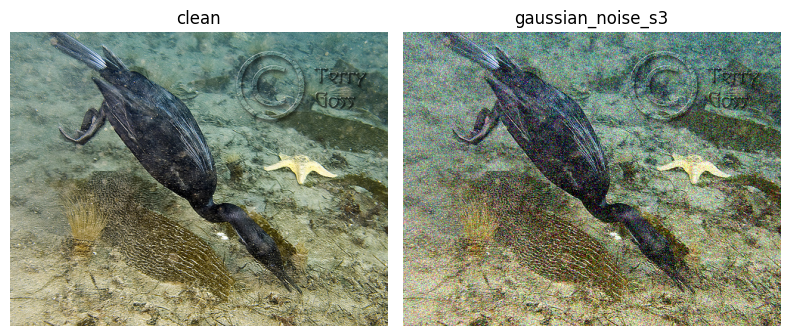

In [17]:
SAMPLE_ID_TO_INSPECT = int(
    sensitivity_df[sensitivity_df.condition == corr_condition]
    .sort_values(["prompt_top1_flip_rate", "prompt_jsd_mean"], ascending=False)
    .iloc[0]
    .sample_id
)

inspect = pred_df[pred_df.sample_id == SAMPLE_ID_TO_INSPECT].copy()
display(
    inspect[["condition", "prompt_name", "true_label", "pred_label", "confidence", "true_prob", "margin_true_vs_best_false", "correct", "semantic_similarity_true_pred"]]
    .sort_values(["condition", "prompt_name"])
    .style.format({
        "confidence": "{:.3f}",
        "true_prob": "{:.3f}",
        "margin_true_vs_best_false": "{:+.3f}",
        "semantic_similarity_true_pred": "{:.3f}",
    })
)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(clean_images[SAMPLE_ID_TO_INSPECT])
axes[0].set_title("clean")
axes[0].axis("off")
axes[1].imshow(corrupted_images[SAMPLE_ID_TO_INSPECT])
axes[1].set_title(corr_condition)
axes[1].axis("off")
plt.tight_layout()
plt.show()